# Module 7 — Wildfire time series and dashboard

**Question:** How do reported California wildfires change month to month, and what can a viewer safely conclude from the plots?

Use the cleaned California `fires_clean.parquet` bundled beside this notebook. One row remains one reported fire. In class, you make the monthly `month`, `fires`, `known_acres`, `sizes_known`, `previous`, `change`, `running`, and `average_3m` columns. Later cells plot your columns and save the table for the dashboard.

Run `uv sync --frozen` in this folder and select its `.venv` kernel. Keep this folder in `~/dso576/07-time-series`.

## 1. Read your cleaned records

`fires_clean.parquet` is included in the Module 7 folder. The cell first checks the current notebook working folder and then `~/dso576/07-time-series`, so it also works when Jupyter starts from a different folder. The file is read only. It retains `DISCOVERY_DATE` and `FIRE_SIZE`; `FIRE_SIZE` is final reported acres.

In [152]:
from pathlib import Path
import pandas as pd

source = Path("fires_clean.parquet")
if not source.is_file():
    source = Path.home() / "dso576" / "07-time-series" / "fires_clean.parquet"
if not source.is_file():
    raise FileNotFoundError(
        f"Could not find fires_clean.parquet in {Path.cwd()} "
        f"or {Path.home() / 'dso576' / '07-time-series'}."
    )

fires = pd.read_parquet(source, columns=["DISCOVERY_DATE", "FIRE_SIZE"])
fires["DISCOVERY_DATE"] = pd.to_datetime(
    fires["DISCOVERY_DATE"], errors="coerce", utc=True).dt.tz_localize(None)
fires["FIRE_SIZE"] = pd.to_numeric(fires["FIRE_SIZE"], errors="coerce")
print("Reading:", source.resolve())
print("Rows:", len(fires))
print("Missing dates:", fires["DISCOVERY_DATE"].isna().sum())
print("Missing sizes:", fires["FIRE_SIZE"].isna().sum())
fires.head()

Reading: /Users/yeganehalimohammadi/07-time-series/fires_clean.parquet
Rows: 283285
Missing dates: 0
Missing sizes: 0


,DISCOVERY_DATE,FIRE_SIZE
0,2005-06-17,0.5
1,2005-07-02,0.1
2,2005-07-20,0.1
3,2005-07-21,0.2
4,2005-05-02,0.1


## 2. See calendar months on a few source dates

These three dates occur in the unchanged Module 6 California source data. `to_period("M")` gives the calendar month; `to_timestamp()` labels it with the month's first day. This cell shows the operation on three dates. It does not build your full monthly table.

In [219]:
example_dates = pd.to_datetime(
    pd.Series(["2005-01-05", "2005-01-17", "2005-02-10"]))
pd.DataFrame({
    "discovered": example_dates,
    "month": example_dates.dt.to_period("M").dt.to_timestamp(),
})

,discovered,month
0,2005-01-05,2005-01-01
1,2005-01-17,2005-01-01
2,2005-02-10,2005-02-01


In [220]:
example_dates.dt.strftime("%b")

0    Jan
1    Jan
2    Feb
dtype: object

## 3. In class: make one row per calendar month

**Business question:** How many California wildfire records were discovered each month, and how many final reported acres are associated with those records? Show every calendar month, including months with no records. Build the `monthly` table that your plots will use.

**Hint:** Keep rows with usable discovery dates in `dated`. Make `dated["month"]` with `to_period("M")` and `to_timestamp()`. Group by month to calculate `fires`, `known_acres`, and `sizes_known`. Use `pd.date_range(..., freq="MS")` and `reindex(..., fill_value=0)` to fill calendar gaps. Restore `month` as a date column and sort it.

The four-row sample and expected output in handout 7.1 show what an absent month means. The unchanged full California source has no missing discovery dates, no missing sizes, and no absent months; your cleaned file can differ.

In [221]:
dated = fires.dropna(subset=["DISCOVERY_DATE"]).copy()
dated["month"] = dated["DISCOVERY_DATE"].dt.to_period("M").dt.to_timestamp()
monthly = dated.groupby("month", as_index=False).agg(
    fires=("DISCOVERY_DATE", "size"),
    known_acres=("FIRE_SIZE", "sum"),
    sizes_known=("FIRE_SIZE", "count"),
)
monthly.head()

,month,fires,known_acres,sizes_known
0,1992-01-01,92,222.3,92
1,1992-02-01,54,225.5,54
2,1992-03-01,48,1885.4,48
3,1992-04-01,259,7364.5,259
4,1992-05-01,1337,12040.7,1337


In [222]:
# In class: complete the calendar, restore month as a date column, and sort monthly.

calendar = pd.date_range(monthly["month"].min(), monthly["month"].max(), freq="MS")
monthly = monthly.set_index("month").reindex(calendar, fill_value=0)
monthly = monthly.rename_axis("month").reset_index().sort_values("month")
monthly.head()


,month,fires,known_acres,sizes_known
0,1992-01-01,92,222.3,92
1,1992-02-01,54,225.5,54
2,1992-03-01,48,1885.4,48
3,1992-04-01,259,7364.5,259
4,1992-05-01,1337,12040.7,1337


**Check your monthly table:** Its `fires` sum should equal the number of dated records. Print the missing-date count so a reader knows whether any records were excluded.

In [223]:
print("Dated records:", len(dated))
print("Monthly total:", monthly["fires"].sum())
print("Missing discovery dates:", fires["DISCOVERY_DATE"].isna().sum())
monthly.head()

Dated records: 283285
Monthly total: 283285
Missing discovery dates: 0


,month,fires,known_acres,sizes_known
0,1992-01-01,92,222.3,92
1,1992-02-01,54,225.5,54
2,1992-03-01,48,1885.4,48
3,1992-04-01,259,7364.5,259
4,1992-05-01,1337,12040.7,1337


## 4. See ordered operations on actual monthly counts

The unchanged California source has 71, 97, 150, and 403 fire records in January–April 2005. This small demonstration shows `shift()`, `diff()`, `cumsum()`, and `rolling()` before you create those columns in your full table. Your cleaned counts may differ.

In [224]:
mini = pd.DataFrame({
    "month": pd.to_datetime(["2005-01-01", "2005-02-01",
                             "2005-03-01", "2005-04-01"]),
    "fires": [71, 97, 150, 403],
}).sort_values("month")
mini.assign(
    previous=mini["fires"].shift(),
    change=mini["fires"].diff(),
    running=mini["fires"].cumsum(),
    average_3m=mini["fires"].rolling(3, min_periods=1).mean(),
)

,month,fires,previous,change,running,average_3m
0,2005-01-01,71,NaN,NaN,71,71.000000
1,2005-02-01,97,71.0,26.0,168,84.000000
2,2005-03-01,150,97.0,53.0,318,106.000000
3,2005-04-01,403,150.0,253.0,721,216.666667


### See how `transform()` keeps the original rows

**Business question:** For each county-month in a small practice report, how many wildfire records were reported in that county across both months? We want that county total next to each original row, so an analyst can compare the row with its county's total.

The numbers below are **illustrative practice data**, not counts from the California source. `groupby(...).sum()` would make one row per county. `groupby(...).transform("sum")` calculates the same county totals but returns one value per original row, in the original order.

In [225]:
mini_counties = pd.DataFrame({
    "month": ["Nov", "Nov", "Dec", "Dec"],
    "county": ["Los Angeles", "Riverside", "Los Angeles", "Riverside"],
    "fires": [4, 3, 6, 1],
})
mini_counties.assign(
    county_total=mini_counties.groupby("county")["fires"].transform("sum")
)

,month,county,fires,county_total
0,Nov,Los Angeles,4,10
1,Nov,Riverside,3,4
2,Dec,Los Angeles,6,10
3,Dec,Riverside,1,4


The `county_total` values are **10, 4, 10, 4**: Los Angeles has `4 + 6 = 10` and Riverside has `3 + 1 = 4`. Notice that the result still has four rows. Later, the county exercise uses `transform()` with a rolling calculation so each county-month gets its own recent average.

## 5. In class: create the columns for the plots

**Business question:** Which months had more or fewer wildfire reports than the preceding month? How many reports have accumulated since the first month, and what does the recent three-month average show? Add the columns needed for these views to the full `monthly` table; the next notebook cells plot them.

**Hint:** Sort `monthly` by month. Use the four snippets above on `monthly["fires"]` to create `previous`, `change`, `running`, and `average_3m`. Calculate March's change and April's three-month average by hand to check your code. Compute on the full table before filtering to a year so January's average can include the preceding November and December.

In [226]:
monthly = monthly.sort_values("month").reset_index(drop=True)
monthly["previous"] = monthly["fires"].shift()
monthly["change"] = monthly["fires"].diff()
monthly["running"] = monthly["fires"].cumsum()
monthly["average_3m"] = monthly["fires"].rolling(3, min_periods=1).mean()
monthly.head()

,month,fires,known_acres,sizes_known,previous,change,running,average_3m
0,1992-01-01,92,222.3,92,NaN,NaN,92,92.000000
1,1992-02-01,54,225.5,54,92.0,-38.0,146,73.000000
2,1992-03-01,48,1885.4,48,54.0,-6.0,194,64.666667
3,1992-04-01,259,7364.5,259,48.0,211.0,453,120.333333
4,1992-05-01,1337,12040.7,1337,259.0,1078.0,1790,548.000000


## 6. Plot the columns you created

Run these supplied plotting calls after your in-class code works. The count and average lines share a chart; the change bars and running count have separate charts. A negative change means fewer reports than the preceding month, while the running count can still increase.

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax = ax , x="month",y="fires", title="Monthly Fires in California", ylabel="Number of Fires", xlabel="Month")
monthly.plot(ax = ax , x="month",y="average_3m", title="Three-Month Average Fires in California", ylabel="Three-Month Average", xlabel="Month")

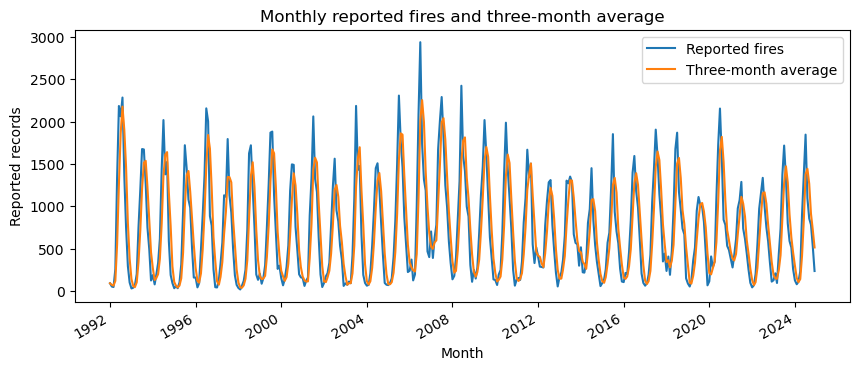

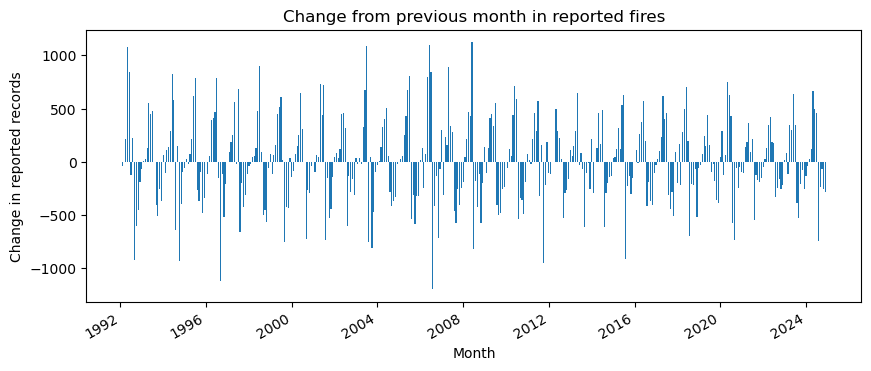

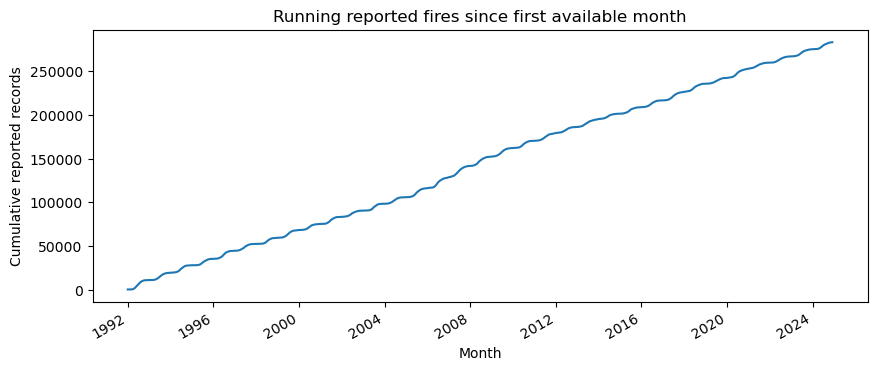

In [228]:
import matplotlib.pyplot as plt

# Compare each month's reported fire records with their three-month average.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"], monthly["fires"], label="Reported fires")
ax.plot(monthly["month"], monthly["average_3m"], label="Three-month average")
ax.set(title="Monthly reported fires and three-month average",
       xlabel="Month", ylabel="Reported records")
ax.legend()
fig.autofmt_xdate()
plt.show()

# Show how the reported record count changed from the previous month.
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly["month"], monthly["change"], width=20)
ax.set(title="Change from previous month in reported fires",
       xlabel="Month", ylabel="Change in reported records")
fig.autofmt_xdate()
plt.show()

# Show the cumulative reported record count since the first available month.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"], monthly["running"])
ax.set(title="Running reported fires since first available month",
       xlabel="Month", ylabel="Cumulative reported records")
fig.autofmt_xdate()
plt.show()

**Check a result:** Choose one month. Recompute its `change` from the two monthly counts and its `average_3m` from up to three counts. Explain one change bar and one point on the running line.

## 7. In-class function exercises

Write each whole function, from `def` through `return`. Run its small input cell, complete the function cell, and compare the displayed result with the expected output. Problem 1 uses verified monthly counts from the unchanged California source data; Problems 2–4 are practice tables. These functions are separate from the `monthly` columns you built for the plots above.

### Problem 1 — monthly changes

**Business question:** For a monthly wildfire briefing, did reports rise or fall from the prior month, what is the recent three-month average, and how many reports have accumulated since November? The briefing crosses into a new year.

**Your task:** Write `month_changes(counts)` to add `previous`, `change`, `average_3m`, and `running` to the ordered input.

**Hint:** Copy `counts`. Apply `shift()`, `diff()`, `rolling(3, min_periods=1).mean()`, and `cumsum()` to `fires`. Keep the rolling window continuous across January, then return the table.

| month | fires | previous | change | average_3m | running |
| --- | ---: | ---: | ---: | ---: | ---: |
| 2004-11 | 96 | missing | missing | 96.00 | 96 |
| 2004-12 | 75 | 96 | -21 | 85.50 | 171 |
| 2005-01 | 71 | 75 | -4 | 80.67 | 242 |
| 2005-02 | 97 | 71 | 26 | 81.00 | 339 |

In [ ]:
counts = pd.DataFrame({
    "month": pd.to_datetime(["2004-11-01", "2004-12-01",
                             "2005-01-01", "2005-02-01"]),
    "fires": [96, 75, 71, 97],
})
counts

In [ ]:
def month_changes(counts):
    '''Add previous, change, average_3m, and running to sorted monthly counts.'''
    raise NotImplementedError("Complete Problem 1 in class")

In [ ]:
month_changes(counts)

### Problem 2 — compare counties separately

**Business question:** A regional analyst wants to compare month-to-month changes and short-term averages for each county. What changed within County A and within County B?

**Your task:** Write `county_trends(counts)` to add `change` and `average_2m` to the practice input, which is sorted by county and month.

**Hint:** Copy `counts`. Group `fires` by county before calculating `diff()` and a two-month rolling mean. Use `transform()` for the rolling calculation so its result lines up with the original rows, as in the county-total example above. Restart each calculation at the first row of each county, then return the table.

| county | month | fires | change | average_2m |
| --- | --- | ---: | ---: | ---: |
| A | Jan | 2 | missing | 2.0 |
| A | Feb | 4 | 2 | 3.0 |
| A | Mar | 6 | 2 | 5.0 |
| B | Jan | 5 | missing | 5.0 |
| B | Feb | 1 | -4 | 3.0 |
| B | Mar | 3 | 2 | 2.0 |

In [ ]:
counts = pd.DataFrame({
    "county": ["A", "A", "A", "B", "B", "B"],
    "month": ["Jan", "Feb", "Mar", "Jan", "Feb", "Mar"],
    "fires": [2, 4, 6, 5, 1, 3],
})
counts

In [ ]:
def county_trends(counts):
    '''Add change and average_2m within each county.'''
    raise NotImplementedError("Complete Problem 2 in class")

In [ ]:
county_trends(counts)

### Problem 3 — first threshold month

**Business question:** A planner reviews each county as soon as its running number of reports reaches a target. In which month does each county reach it for the first time?

**Your task:** Write `first_threshold(counts, target=5)` to add `running`, `hit`, and `reached` to the practice input, which is sorted by county and month. `hit` stays true after the target; `reached` marks only the first hit.

**Hint:** Copy `counts`. Calculate a separate `cumsum()` for each county. Compare `running` with `target` for `hit`, then use the first true `hit` within each county for `reached`. Return the table.

| county | month | fires | running | hit | reached |
| --- | --- | ---: | ---: | --- | --- |
| A | Jan | 2 | 2 | False | False |
| A | Feb | 4 | 6 | True | True |
| A | Mar | 1 | 7 | True | False |
| B | Jan | 1 | 1 | False | False |
| B | Feb | 1 | 2 | False | False |
| B | Mar | 3 | 5 | True | True |

In [ ]:
counts = pd.DataFrame({
    "county": ["A", "A", "A", "B", "B", "B"],
    "month": ["Jan", "Feb", "Mar", "Jan", "Feb", "Mar"],
    "fires": [2, 4, 1, 1, 1, 3],
})
counts

In [ ]:
def first_threshold(counts, target=5):
    '''Add running, hit, and reached within each county.'''
    raise NotImplementedError("Complete Problem 3 in class")

In [ ]:
first_threshold(counts)

### Problem 4 — missing calendar month

**Business question:** This practice report treats an omitted month as zero reported records. It jumps from January to March. What should the complete month-to-month report show for February and March?

**Your task:** Write `fill_months(counts)` to insert every month from the first through last observed month, put zero `fires` in an absent month, and add `change`. Keep `month` as a date column.

**Hint:** Build a month-start calendar with `pd.date_range(..., freq="MS")`. Set `month` as the index, reindex to the calendar with zeros, restore `month` as a column, calculate `diff()`, and return the table.

| month | fires | change |
| --- | ---: | ---: |
| 2025-01-01 | 2 | missing |
| 2025-02-01 | 0 | -2 |
| 2025-03-01 | 3 | 3 |

In [ ]:
counts = pd.DataFrame({
    "month": pd.to_datetime(["2025-01-01", "2025-03-01"]),
    "fires": [2, 3],
})
counts

In [ ]:
def fill_months(counts):
    '''Insert absent months and add change.'''
    raise NotImplementedError("Complete Problem 4 in class")

In [ ]:
fill_months(counts)

## 8. Save the dashboard table

The dashboard reads your small monthly file from `~/dso576/07-time-series/outputs`. Check its date range and totals before saving.

In [ ]:
print("First month:", monthly["month"].min())
print("Last month:", monthly["month"].max())
print("Dated records:", len(dated))
print("Monthly total:", monthly["fires"].sum())
print("Known-size records:", monthly["sizes_known"].sum())
print("Columns:", monthly.columns.tolist())

In [ ]:
output_dir = Path.home() / "dso576" / "07-time-series" / "outputs"
output_dir.mkdir(exist_ok=True)
monthly.to_csv(output_dir / "monthly_wildfire.csv", index=False)

## 9. Open and review the dashboard

Run `uv run streamlit run dashboard.py` in Terminal or PowerShell. The app reads the columns **you built** and shows a year selector, yearly totals, a monthly count with its three-month average, change bars, a running count, and known reported acres.

1. Compare one selected year's reported-fire metric with that year's `fires` rows in your notebook.
2. Check that January's average includes the previous year's months when available.
3. State one valid observation and one caveat about reporting or final reported sizes.

Your checked year, observation, and caveat: